In [1]:
import numpy as np
import glob
import os

In [2]:
# ---- OVERDETERMINED METHOD ----

In [3]:
# ==========================================
# STEP 1: BASIC QUANTUM DEFINITIONS
# ==========================================
# Define single-photon basis vectors 
H = np.array([[1], [0]], dtype=complex)
V = np.array([[0], [1]], dtype=complex)
D = (H + V) / np.sqrt(2)
A = (H - V) / np.sqrt(2)
R = (H + 1j * V) / np.sqrt(2)  # Right Circular
L = (H - 1j * V) / np.sqrt(2)  # Left Circular

# Mathematical function to create a projection operator P = |psi><psi|
def projector(ket):
    return ket @ ket.conj().T

# "Catalog" of the 6 possible projectors in our setup
P_base = {
    'H': projector(H), 'V': projector(V),
    'D': projector(D), 'A': projector(A),
    'R': projector(R), 'L': projector(L)
}

# Standard Pauli Matrices
sigma_0 = np.array([[1, 0], [0, 1]], dtype=complex) # I (Identity)
sigma_1 = np.array([[0, 1], [1, 0]], dtype=complex) # X (Diagonal basis)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex) # Y (Circular basis)
sigma_3 = np.array([[1, 0], [0, -1]], dtype=complex) # Z (Computational basis)
pauli_matrices = [sigma_0, sigma_1, sigma_2, sigma_3]

# Generate the 16 Gamma_j matrices (Tensor product of Pauli matrices for 2 photons)
Gamma = []
for pauli_photon1 in pauli_matrices:
    for pauli_photon2 in pauli_matrices:
        Gamma.append(np.kron(pauli_photon1, pauli_photon2)) #tensor product(kron)


In [4]:
# ==========================================
# STEP 2: EXPERIMENTAL DATA EXTRACTION
# ==========================================
def process_file(filepath):
    """
    Reads the histogram txt file, finds the coincidence peak, 
    subtracts background noise, and returns the net coincidence counts.
    """
    try:
        data = np.loadtxt(filepath, skiprows=1)
        times = data[:, 0]
        counts = data[:, 1]
        
        # Dynamic search for the peak center
        peak_center = times[np.argmax(counts)]
        
        # Integrate the peak (+/- 500 ps window)
        idx_peak = np.where((times >= peak_center - 500) & (times <= peak_center + 500))[0]
        total_coincidences = np.sum(counts[idx_peak])
        
        # Calculate flat background noise (-6000 to -4000 ps)
        idx_bg = np.where((times >= -6000) & (times <= -4000))[0]
        avg_noise = np.mean(counts[idx_bg])
        
        # Subtract noise to get net counts (ensure it doesn't drop below 0)
        net_counts = total_coincidences - (avg_noise * len(idx_peak))
        return max(0, net_counts)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return 0

In [5]:
# ==========================================
# STEP 3: BUILD SYSTEM AND DESIGN MATRIX (A)
# ==========================================
files = glob.glob("Bidirectional_histogram*.txt") # Selects all the files that start with "Bidirectional_histogram" and end with ".txt"
files.sort() # Sort alphabetically to ensure consistent vector order

n_vector = []
P_k_matrices = [] #projector for each physical measurement
extracted_counts_dict = {}

valid_bases = ['H', 'V', 'D', 'A', 'R', 'L']
processed_count = 0

for file in files:
    # 1. Clean the filename to extract just the two letters
    base_name = os.path.basename(file).replace("Bidirectional_histogram_", "").replace("Bidirectional_histogram.", "").replace(".txt", "").strip().upper()
    
    # 2. Check if we actually got exactly 2 valid letters
    if len(base_name) >= 2:
        photon_1, photon_2 = base_name[0], base_name[1]
        
        # 3. Verify both letters exist in our catalog before proceeding
        if photon_1 in valid_bases and photon_2 in valid_bases:
            
            # Get net coincidences
            net_counts = process_file(file)
            n_vector.append(net_counts)
            
            # Only keep the 2-letter key for the dictionary (e.g., 'HH')
            clean_key = f"{photon_1}{photon_2}"
            extracted_counts_dict[clean_key] = net_counts
            
            # Build the 2-photon projector
            P_k = np.kron(P_base[photon_1], P_base[photon_2])
            P_k_matrices.append(P_k)
            
            processed_count += 1
        else:
            print(f"Skipping file (Invalid bases '{photon_1}' or '{photon_2}'): {file}")
    else:
        print(f"Skipping file (Name too short): {file}")

if processed_count != 36:
    print(f"\nCRITICAL WARNING: Processed {processed_count} valid files instead of 36.")
    print("The Moore-Penrose pseudoinverse might fail or give wrong results. Check your folder!")
else:
    print(f"Successfully processed exactly 36 valid measurement files.")

# --- DISPLAY EXTRACTED COUNTS FOR MANUAL VERIFICATION ---
print("\n" + "="*65)
print(" EXPERIMENTAL NET COINCIDENCES (PER STATE)")
print("="*65)
keys = list(extracted_counts_dict.keys())
keys.sort() # Sort alphabetically for display
for i in range(0, len(keys), 4):
    chunk = keys[i:i+4]
    line = "  |  ".join([f"{k}: {extracted_counts_dict[k]:8.1f}" for k in chunk])
    print(line)
print("="*65 + "\n")

n_vector = np.array(n_vector) # Our complete measurement vector


# Build Design Matrix A (rows = processed_count x 16 columns)
A = np.zeros((processed_count, 16), dtype=complex)
for k in range(processed_count):         
    for j in range(16):     
        A[k, j] = np.trace(Gamma[j] @ P_k_matrices[k])

A = np.real(A)

Successfully processed exactly 36 valid measurement files.

 EXPERIMENTAL NET COINCIDENCES (PER STATE)
AA:   7989.8  |  AD:  10883.3  |  AH:   9598.2  |  AL:   9681.3
AR:   9242.4  |  AV:   8209.2  |  DA:  11313.3  |  DD:   8473.3
DH:   8634.3  |  DL:  10356.4  |  DR:   9662.0  |  DV:  11242.2
HA:  10445.3  |  HD:   8028.5  |  HH:   6681.9  |  HL:   8484.8
HR:   9342.3  |  HV:  10989.2  |  LA:   9818.3  |  LD:   9486.8
LH:   9553.4  |  LL:   9874.8  |  LR:   8157.3  |  LV:   8748.7
RA:   9818.4  |  RD:  10406.3  |  RH:   9343.7  |  RL:   9016.3
RR:  10802.8  |  RV:   9034.6  |  VA:   8267.4  |  VD:  10003.3
VH:  11925.8  |  VL:   9417.3  |  VR:  10181.3  |  VV:   7824.7



In [6]:
# ==========================================
# STEP 4: PSEUDOINVERSE AND RECONSTRUCTION
# ==========================================

# Calculate t_opt = (A^T A)^-1 A^T * n using numpy's built-in pinv (Pseudo-INVerse)
t_opt = np.linalg.pinv(A) @ n_vector

# Build the "raw" density matrix using the optimal Stokes parameters
rho_raw = np.zeros((4, 4), dtype=complex)

for j in range(16):
    rho_raw += (t_opt[j] * Gamma[j]) / 4

# Normalize using Method B (forcing Trace = 1) 
rho_matrix = rho_raw / np.trace(rho_raw)

# Calculate the eigenvalues
autovalores = np.linalg.eigvalsh(rho_matrix)

# Density Matrix Puriry
purity = np.trace(rho_matrix @ rho_matrix)

In [7]:
# ==========================================
# STEP 5: DISPLAY RESULTS
# ==========================================

# Configure numpy to avoid messy scientific notation
np.set_printoptions(precision=4, suppress=True, linewidth=120)

print("\n" + "="*65)
print("                       DENSITY MATRIX (\u03C1)")
print("="*65)
print(rho_matrix)
print(f"\nTrace Verification: {np.real(np.trace(rho_matrix)):.4f}")
print(f"\nEigenvalues of the matrix: {autovalores}")
print(f'\nPurity = {np.real(purity):.4f}')


                       DENSITY MATRIX (ρ)
[[ 0.1858+0.j     -0.0282-0.0018j -0.0174-0.0029j -0.061 -0.0044j]
 [-0.0282+0.0018j  0.2982+0.j     -0.0147-0.0078j  0.0353-0.0094j]
 [-0.0174+0.0029j -0.0147+0.0078j  0.3128+0.j      0.0266-0.0006j]
 [-0.061 +0.0044j  0.0353+0.0094j  0.0266+0.0006j  0.2032+0.j    ]]

Trace Verification: 1.0000

Eigenvalues of the matrix: [0.1324 0.2148 0.3172 0.3356]

Purity = 0.2769


In [8]:
from scipy.optimize import minimize

# ==========================================
# STEP 6: MAXIMUM LIKELIHOOD ESTIMATION (MLE) + CHOLESKY
# ==========================================

def mle_cost_function(t, n_measured, projectors, N_total):
    """
    Objective function: Builds T, calculates parameterized rho, 
    and returns the Exact Poisson Negative Log-Likelihood.
    """
    # 1. Build lower triangular matrix T (16 real parameters)
    T = np.zeros((4, 4), dtype=complex)
    T[0,0] = t[0]
    T[1,0] = t[4] + 1j*t[5]
    T[1,1] = t[1]
    T[2,0] = t[10] + 1j*t[11]
    T[2,1] = t[6] + 1j*t[7]
    T[2,2] = t[2]
    T[3,0] = t[14] + 1j*t[15]
    T[3,1] = t[12] + 1j*t[13]
    T[3,2] = t[8] + 1j*t[9]
    T[3,3] = t[3]

    # 2. Parameterization (Guarantees Positive Semi-Definite & Trace 1)
    T_dagger = T.conj().T
    rho_trial = (T_dagger @ T) / np.trace(T_dagger @ T)

    # 3. Calculate statistical error (Exact Poisson Log-Likelihood)
    total_error = 0.0
    for k in range(len(n_measured)):
        expected_prob = np.real(np.trace(rho_trial @ projectors[k]))
        n_expected = N_total * expected_prob
        
        # Epsilon critical safety net to prevent np.log(0) -> -inf
        if n_expected < 1e-9:
            n_expected = 1e-9
            
        # Exact Poisson Negative Log-Likelihood: mu - n*ln(mu)
        total_error += n_expected - n_measured[k] * np.log(n_expected)
        
    return total_error


# --- STARTING MLE OPTIMIZATION (EXACT POISSON) ---


# Calculate the total number of photons in a complete basis.
# Assuming indices 0 to 3 of n_vector correspond to HH, HV, VH, VV.
# If your order is different (e.g., alphabetical), you must sum the counts of a complete basis.
N_total = extracted_counts_dict['HH'] + extracted_counts_dict['HV'] + extracted_counts_dict['VH'] + extracted_counts_dict['VV']

# Initial vector t0 (Identity Matrix: t1,t2,t3,t4 = 1, rest = 0)
# This is the standard, unbiased starting point (Maximally Mixed State)
t_initial = np.zeros(16)
t_initial[0:4] = 1.0 

# Optimizer execution (L-BFGS-B algorithm)
opt_result = minimize( # returns the coordinates of the lowest point of a mathematical topology [f(x)]
    mle_cost_function, 
    t_initial, # variable values
    args=(n_vector, P_k_matrices, N_total), # fixed values
    method='L-BFGS-B', # Numerical Algorithm
    options={'maxiter': 5000, 'disp': False} # Boundary Conditions (maxiter=steps)
)

if opt_result.success:
    print("-> MLE Optimization converged successfully.")
else:
    print("-> Warning: The optimizer did not fully converge.")

# ==========================================
# STEP 7: RECONSTRUCTION OF THE OPTIMAL MATRIX
# ==========================================
t_opt = opt_result.x

T_opt = np.zeros((4, 4), dtype=complex)
T_opt[0,0] = t_opt[0]
T_opt[1,0] = t_opt[4] + 1j*t_opt[5]
T_opt[1,1] = t_opt[1]
T_opt[2,0] = t_opt[10] + 1j*t_opt[11]
T_opt[2,1] = t_opt[6] + 1j*t_opt[7]
T_opt[2,2] = t_opt[2]
T_opt[3,0] = t_opt[14] + 1j*t_opt[15]
T_opt[3,1] = t_opt[12] + 1j*t_opt[13]
T_opt[3,2] = t_opt[8] + 1j*t_opt[9]
T_opt[3,3] = t_opt[3]

# Strict final matrix
rho_mle = (T_opt.conj().T @ T_opt) / np.trace(T_opt.conj().T @ T_opt)

#Density Matrix MLE Puriry
purity_mle = np.trace(rho_mle @ rho_mle)

# Display results
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("\n" + "="*65)
print("      OPTIMAL DENSITY MATRIX (MLE EXACT POISSON + CHOLESKY)")
print("="*65)
print(rho_mle)

print(f"\nFinal Trace: {np.real(np.trace(rho_mle)):.4f}")
print(f"\nMLE Eigenvalues: {np.linalg.eigvalsh(rho_mle)}")
print(f'\nPurity = {np.real(purity_mle):.4f}')

-> MLE Optimization converged successfully.

      OPTIMAL DENSITY MATRIX (MLE EXACT POISSON + CHOLESKY)
[[ 0.1843+0.j     -0.0289-0.002j  -0.0177-0.0026j -0.0603-0.0044j]
 [-0.0289+0.002j   0.2989+0.j     -0.0139-0.0071j  0.0349-0.0098j]
 [-0.0177+0.0026j -0.0139+0.0071j  0.3137+0.j      0.0277-0.0001j]
 [-0.0603+0.0044j  0.0349+0.0098j  0.0277+0.0001j  0.2031+0.j    ]]

Final Trace: 1.0000

MLE Eigenvalues: [0.1322 0.2138 0.3175 0.3365]

Purity = 0.2772


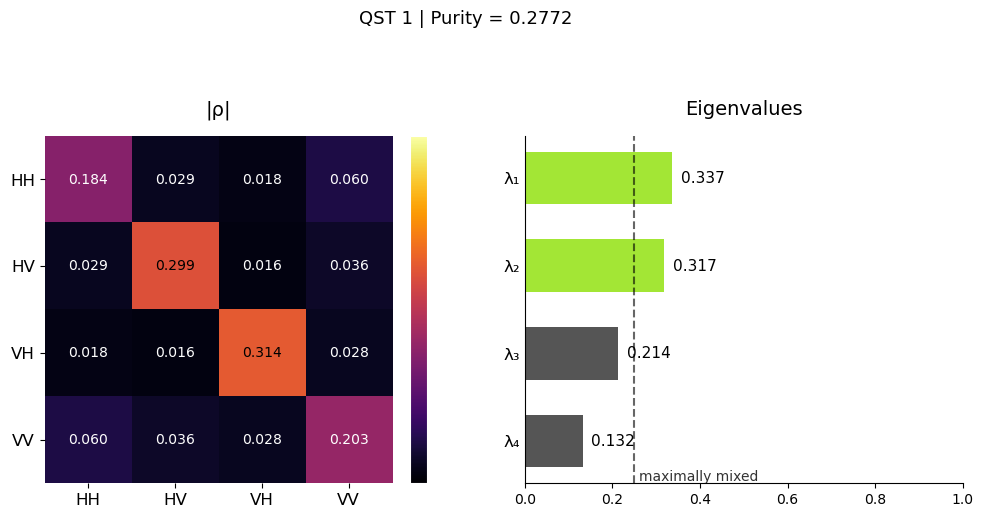

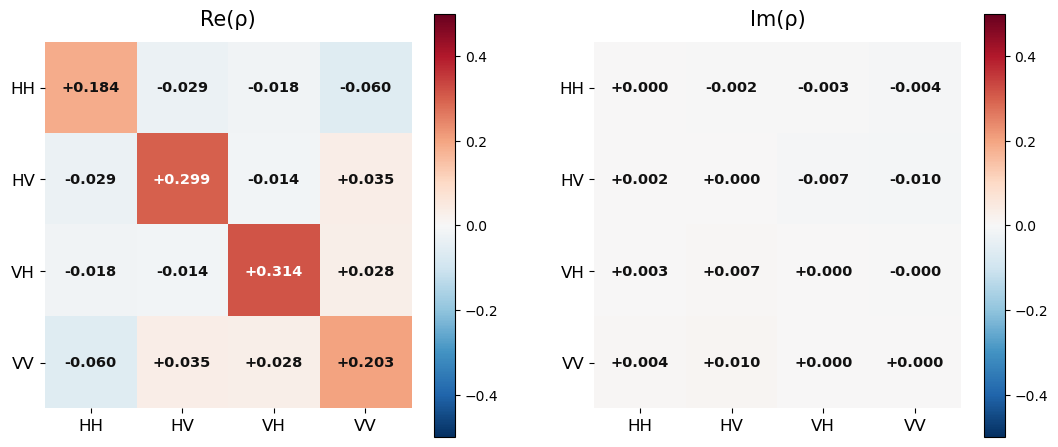

In [9]:
import matplotlib.pyplot as plt

# 1. Define the complex density matrix
rho = np.array([
    [ 0.1843+0.j,     -0.0289-0.002j,  -0.0177-0.0026j, -0.0603-0.0044j],
    [-0.0289+0.002j,   0.2989+0.j,     -0.0139-0.0071j,  0.0349-0.0098j],
    [-0.0177+0.0026j, -0.0139+0.0071j,  0.3137+0.j,      0.0277-0.0001j],
    [-0.0603+0.0044j,  0.0349+0.0098j,  0.0277+0.0001j,  0.2031+0.j    ]
])
color_1 = 'black'
# Compute absolute values and eigenvalues
rho_abs = np.abs(rho)
# Using eigh since density matrices are Hermitian, guarantees real eigenvalues
eigenvalues = np.linalg.eigh(rho)[0] 
eigenvalues = np.sort(eigenvalues)[::-1] # Sort descending

# 2. Figure setup
bg_color = 'white'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5), facecolor=bg_color)
fig.suptitle("QST 1 | Purity = 0.2772", 
             color=color_1, fontsize=13, y=0.98)

# ==========================================
# LEFT SUBPLOT: Heatmap of Absolute Values
# ==========================================
ax1.set_facecolor(bg_color)

# Plot heatmap
im = ax1.imshow(rho_abs, cmap='inferno', vmin=0, vmax=0.5)

# Axis ticks and labels
labels = ['HH', 'HV', 'VH', 'VV']
ax1.set_xticks(np.arange(4))
ax1.set_yticks(np.arange(4))
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_yticklabels(labels, fontsize=12)
ax1.set_title("|ρ|", color=color_1, fontsize=14, pad=15)

# Remove spines for heatmap
for spine in ax1.spines.values():
    spine.set_visible(False)

# Annotate each cell
for i in range(4):
    for j in range(4):
        val = rho_abs[i, j]
        text_color = 'white' if val < 0.25 else 'black'
        ax1.text(j, i, f"{val:.3f}", ha="center", va="center", color=text_color)

# Add white colorbar
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
cbar.outline.set_edgecolor('white')

# ==========================================
# RIGHT SUBPLOT: Eigenvalues Bar Chart
# ==========================================
ax2.set_facecolor(bg_color)

y_pos = np.arange(4)
labels_eig = ['λ₁', 'λ₂', 'λ₃', 'λ₄']

# Determine colors for bars (UPDATED: > 0.15 threshold and #555555 base color)
bar_colors = ['#a3e635' if val > 0.25 else '#555555' for val in eigenvalues]

# Plot horizontal bars
bars = ax2.barh(y_pos, eigenvalues, color=bar_colors, height=0.6)

# Axis configuration
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels_eig, color=color_1, fontsize=12)
ax2.invert_yaxis()  # Highest eigenvalue at the top
ax2.set_xlim(0, 1)
ax2.set_title("Eigenvalues", color=color_1, fontsize=14, pad=15)

# Tick colors and spine styling
ax2.tick_params(axis='x', colors=color_1)
ax2.tick_params(axis='y', colors=color_1, length=0) # Hide y-ticks but keep labels
for spine in ['bottom', 'left']:
    ax2.spines[spine].set_color(color_1)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Annotate bars with values
for i, val in enumerate(eigenvalues):
    ax2.text(val + 0.02, i, f"{val:.3f}", color=color_1, va='center', fontsize=11)

# Vertical dashed line for maximally mixed state
ax2.axvline(x=0.25, color=color_1, linestyle='--', alpha=0.6)
ax2.text(0.26, 3.4, "maximally mixed", color=color_1, va='center', alpha=0.8, fontsize=10)

# ==========================================
# FINAL ADJUSTMENTS AND EXPORT
# ==========================================
plt.tight_layout(pad=3.0)
plt.savefig('qst1_presentation.png', dpi=180, bbox_inches='tight', facecolor=bg_color)
plt.show()

# ===========================================
# RE & IM PART
# ===========================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=bg_color)

for ax, data, title in zip(axes, [np.real(rho), np.imag(rho)], ['Re(ρ)', 'Im(ρ)']):
    ax.set_facecolor(bg_color)
    im = ax.imshow(data, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    for i in range(4):
        for j in range(4):
            val = data[i, j]
            norm = (val + 0.5) / 1.0
            color = 'white' if (norm < 0.35 or norm > 0.72) else '#111'
            ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                    fontsize=10.5, fontweight='bold', color=color)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(labels, color=color_1, fontsize=12)
    ax.set_yticklabels(labels, color=color_1, fontsize=12)
    ax.set_title(title, color=color_1, fontsize=15, pad=12)
    for spine in ax.spines.values(): spine.set_visible(False)
    cb = plt.colorbar(im, ax=ax, ticks=[-0.4,-0.2,0,0.2,0.4])
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=color_1)

plt.savefig('qst1_re_im.png', dpi=180, bbox_inches='tight', facecolor=bg_color)